# The Karplus-Strong algorithm

O algoritmo de Karplus-Strong (KS) é uma laço de "*feedback*" digital simples com um "*buffer*" interno de $M$ amostras:
- O buffer é preenchido com um conjunto de valores iniciais.
- O laço, ao ser executado, produz um sinal de saída arbitráriamente longo.

Embora elementar, o laço KS pode ser utilizado para sintetizar sons musicais interessantes, como veremos neste Notebook.

Comecemos com uma implementação básica do laço KS (ou *malha* KS):

In [35]:
def KS_1(x, N):
    ''' 
    Cria um sinal com o algoritmo Karplus-Strong
        
    x : Sinal de entrada
    N : Tamanho do sinal (em número de amostras)
    '''
    
    # Dado o buffer initial x, producir uma saída de N-amostras
    # pela concatenação de cópias idênticas do buffer
    y = x
    
    while len(y) < N:
        # Continuar anexando até atingir (ou exceder) o comprimento requisitado
        y = np.append(y, x)
    
    # Limpar o excesso
    y = y[0: N+1]
    
    return y

Vamos a experimentar!
Mas, por mais impacientes que sejamos, ainda precisamos arrumar alguns detalhes.

Primeiro, precisamos incluir as bibliotecas Python necessárias:

In [36]:
import numpy as np
import matplotlib.pyplot as plt

In [37]:
import os
import sys
sys.path.append('../../')
from lib.myPlotLib import *
from lib.myAudioProcessingLib import * # <- A nossa biblioteca de processamento de áudio

In [5]:
%matplotlib inline

In [33]:
import os
plt.rcParams['figure.figsize'] = (14, 4)

AUDIO_PATH = '../../sounds'   # Pasta de arquivos de som (corrigido)
MIDI_PATH  = '../../midi'     # Pasta de arquivos MIDI (sem uso ativo)


Depois, dado que estamos trabalhando com áudio, precisams definir o "relógio" interno do sistema, também conhecido como taxa de amostragem (*sampling rate*)

In [7]:
fs = 16000 # 16 KHz

Com esta taxa de amostragem, como o período do sinal gerado é igual ao comprimento do buffer inicial, poderemos calcular a frequência fundamental do som resultante.

Por exemplo, se iniciamos o algoritmo KS com um vetor de 50 valores, o buffer inicial caberá $16000 / 50 = 320$ vezes em um segundo de amostras.
Em outras palavras, a frequência resultante será de $320$Hz, o que corresponde aproximadamente à nota $E4$ em um piano (em notação de ''*[cifras](https://pt.wikipedia.org/wiki/Cifra_(m%C3%BAsica)#Regra_de_forma%C3%A7%C3%A3o)*'').

Perceba que nós ainda não falamos sobre o que usar como valores iniciais para o buffer.
Bem, o mais legal do KS é que podemos usar praticamente qualquer coisa que quisermos.
Na verdade, usar valores aleatórios lhe dará um som bom.
Como prova, considere este conjunto de dados inicial:

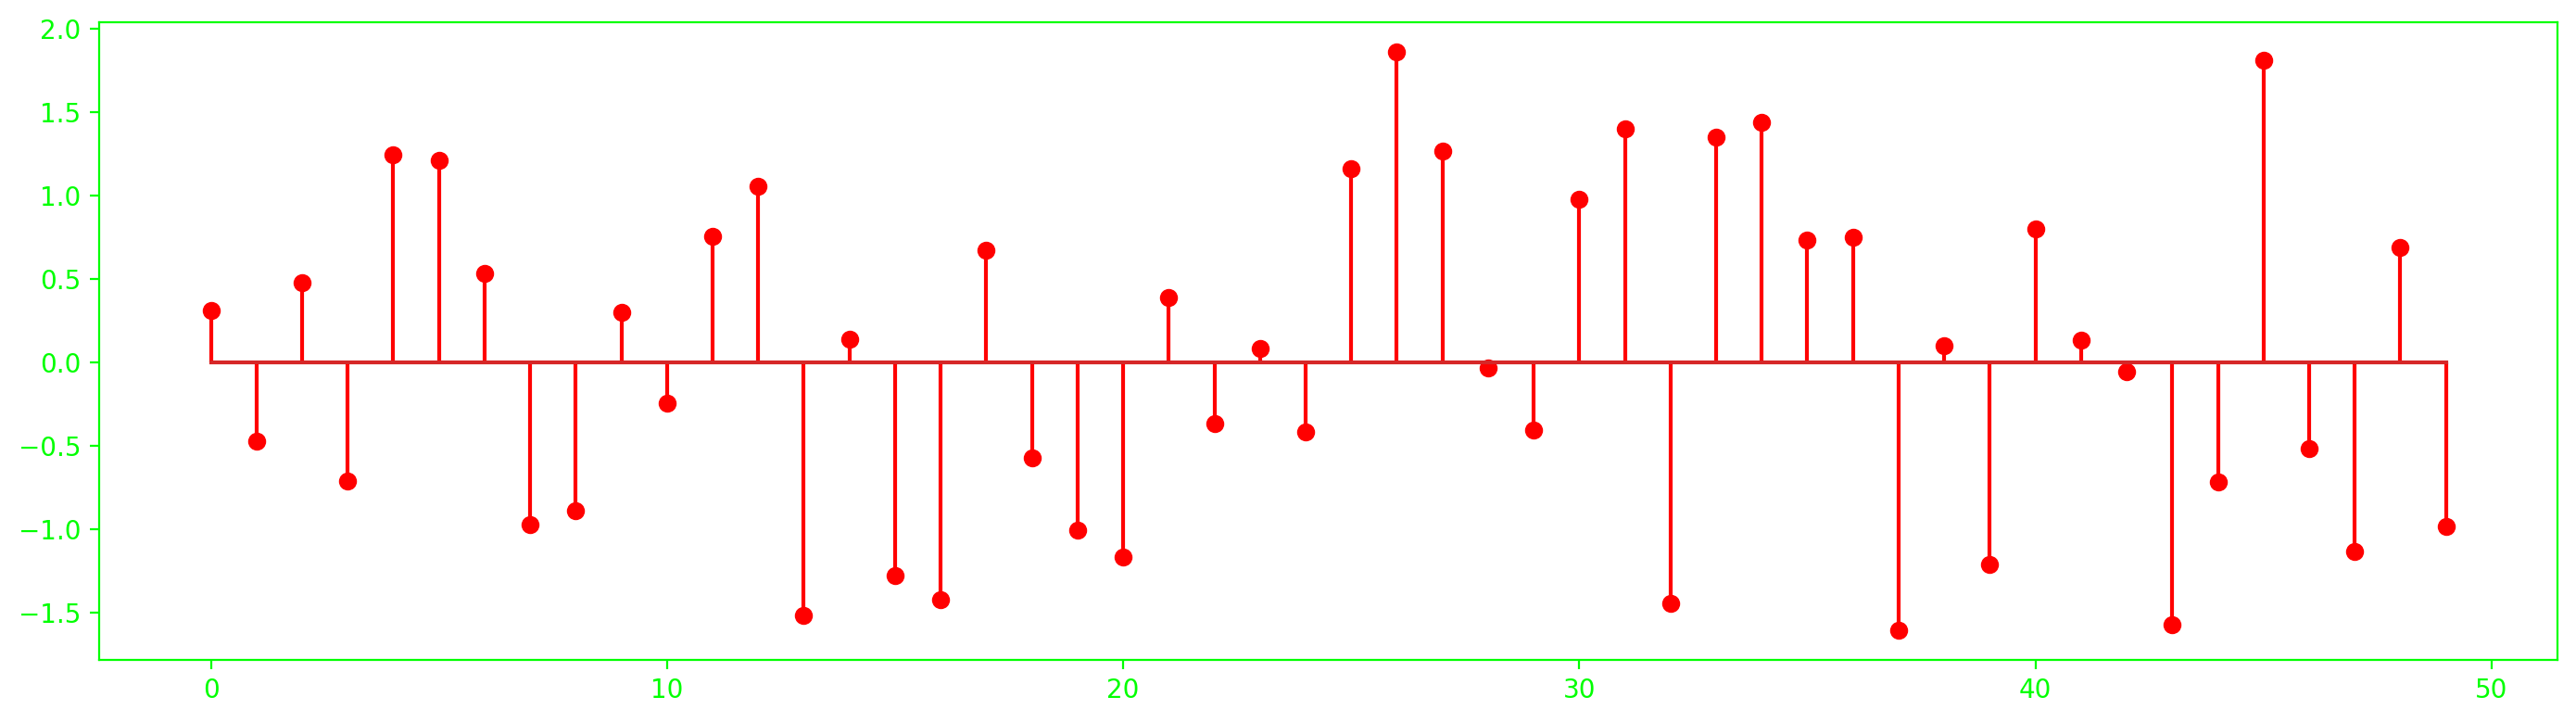

In [8]:
x = np.random.randn(50) # Sinal aleatorio inicial (ruido branco)

fig, ax = plt.subplots()
ax.stem(x, 'r')
plt.title('Buffer Inicial Aleatório')
plt.show()


Agora, vamos gerar um *clipe* de áudio de 2 segundos:

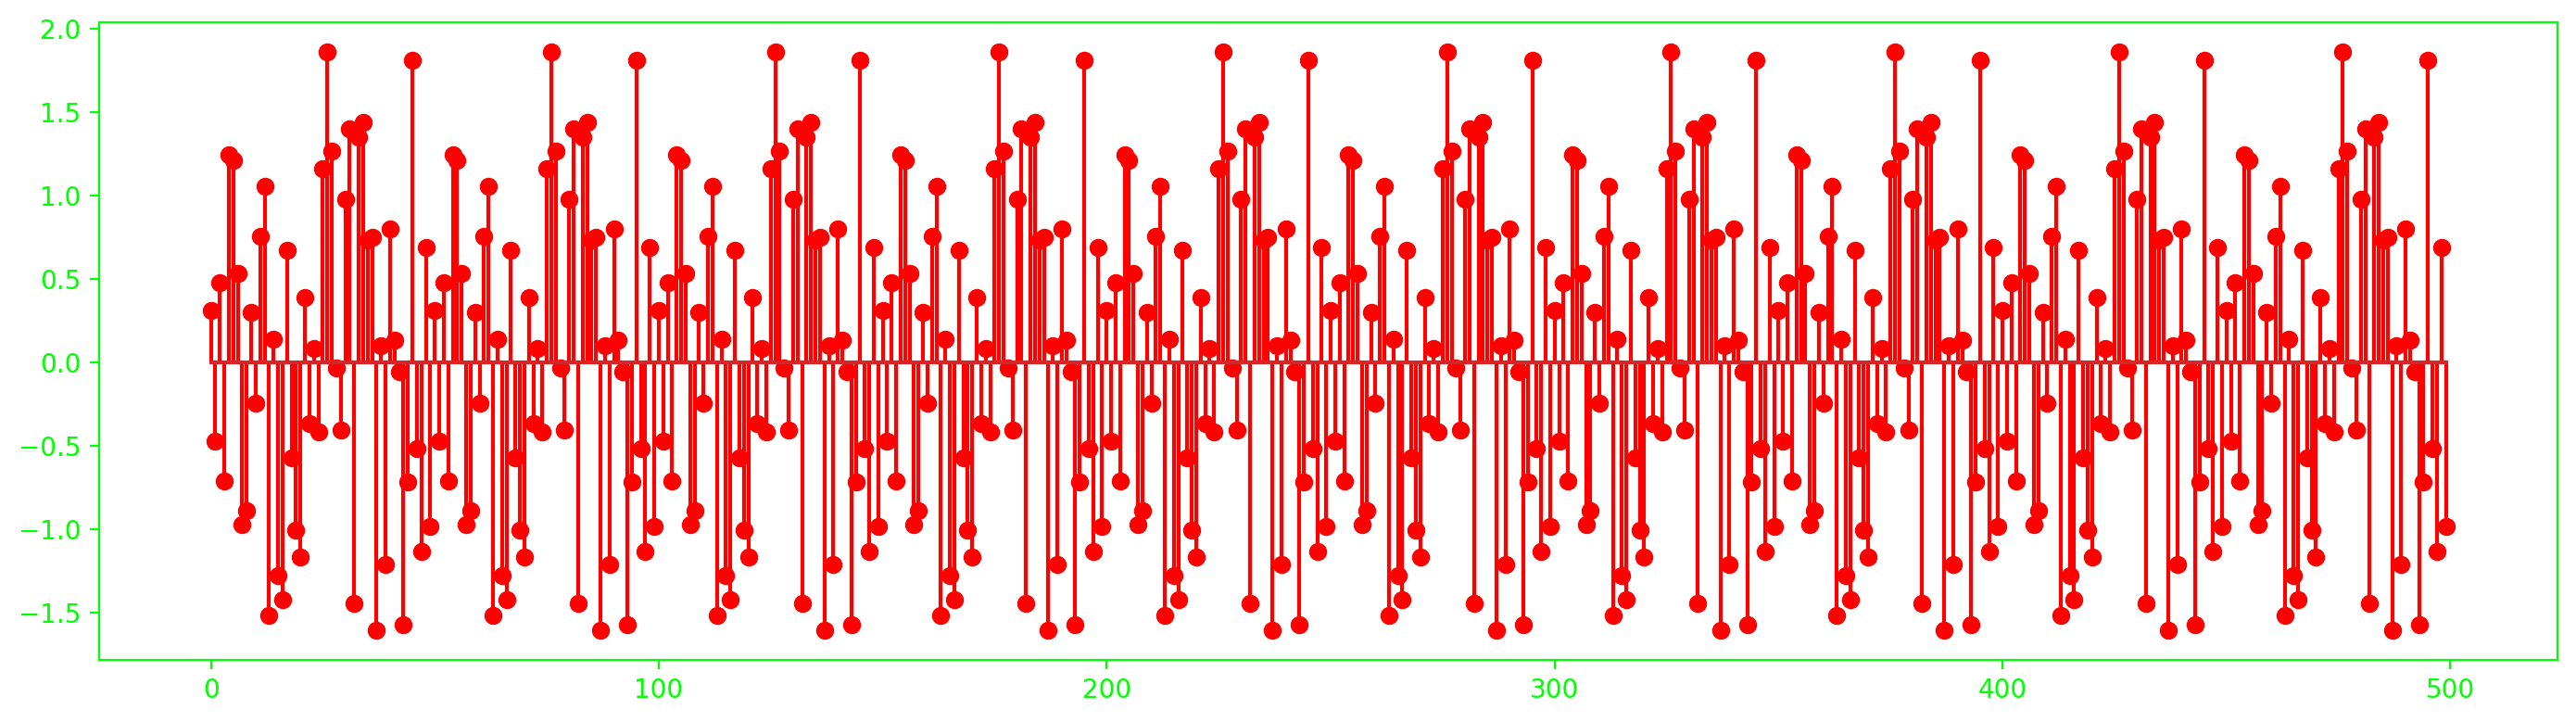

In [9]:
y = KS_1(x, 2*fs) # 2 segundos de áudio

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(y[0:500], 'b')
plt.title('Sinal KS_1 (primeiras 500 amostras)')
plt.show()


In [10]:
play(y, fs)

In [11]:
# Vamos tocar uma oitava abaixo: dobrando o comprimento do buffer inicial
x = np.random.randn(100) # Dobro do tamanho -> Metade da frequência (Oitava abaixo)
y = KS_1(x, 2*fs)

from IPython.display import Audio
Audio(data=y, rate=fs)


## Perguntas
1. Qual distribuição de probabilidade segue o sinal de entrada $x[n]$?
2. E se mudar de distribuição, o que acontece com o sinal de saída $y[n]$?

Mostre as saídas de áudio para distribuições diferentes na entrada

In [12]:
# 1. O sinal de entrada inicial `x[n] = np.random.randn(50)` segue uma distribuição **Normal (Gaussiana)**, $\mathcal{N}(0, 1)$, o que equivale a ruído branco térmico.
# 2. Se mudarmos para uma distribuição Uniforme `np.random.uniform(-1, 1, 50)`, a frequência fundamental do som gerado NÃO muda, pois ela depende exclusivamente do tamanho do buffer ($M=50$).
# O que muda é a percepção do timbre inicial (o 'ataque' da nota), pois diferentes distribuições de ruído injetam diferentes envelopes espectrais de energia na corda.

import numpy as np
from IPython.display import Audio, display

x_gauss = np.random.randn(50)
x_unif  = np.random.uniform(-1, 1, 50)

y_gauss = KS_1(x_gauss, 2*fs)
y_unif  = KS_1(x_unif, 2*fs)

print('Áudio com Ruído Gaussiano:')
display(Audio(data=y_gauss, rate=fs))

print('Áudio com Ruído Uniforme (pode soar ligeiramente mais áspero/metálico no ataque):')
display(Audio(data=y_unif, rate=fs))


OK, então o algoritmo K-S funciona! Do ponto de vista do processamento de sinais, podemos descrever o sistema com o seguinte diagrama de blocos (desconsidere o fator "$\alpha$" por um momento)

<img src="./figures/ks.png" alt="" width="600"/>

A saída pode ser expressa como
$$
y[n] = x[n] + y[n - M]
$$

Assumindo que a entrada é o seguinte sinal de suporte finito
$$
x[n] = \begin{cases}
    0 & \mbox{for $n < 0$} \\
    b_n & \mbox{for $0 \le n < M$} \\
    0 & \mbox{for $n \ge M$}
  \end{cases}
$$

Implementemos o algoritmo KS como um laço de processamento de sinais!

In [13]:
def KS_2(x, N):
    ''' 
    Cria um sinal com o algoritmo Karplus-Strong
    
    x : Sinal de entrada
    N : Tamanho do sinal (em número de amostras)
    '''
    
    # Comprimento da entrada
    M = len(x)
    # Preparando a saída
    y = np.zeros(N)
    
    # Esta NAO é um implementação eficiente, porém ela mostra o princípio geral
    # Assumimos condições iniciais zeradas (y[n] = 0 para n < 0)
    for n in range(0, N):
        y[n] = (x[n] if n < M else 0) + (y[n-M] if n-M >= 0 else 0)
        
    return y

In [14]:
# Deveria funcionar (ainda) ...
x = np.random.randn(50)
y = KS_2(x, 2*fs)

play(y, fs)

Observando o diagrama de blocos, podemos visualizar uma modificação simples que adiciona muito realismo ao som:
- Definindo $\alpha$ para um valor próximo, mas menor que um, podemos introduzir um *decaimento* na nota, o que irá produzir sons parecidos aos de um **violão**!

$$
\Large
    y[n] = x[n] + {\color{red}\alpha} y[n - M]
$$

In [15]:
def KS_3(x, N, alpha=0.99):
    ''' 
    Cria um sinal com o algoritmo Karplus-Strong
        
    x     : Sinal de entrada
    N     : Tamanho do sinal (em número de amostras)
    alpha : Fator de decaimento
    '''
    
    M = len(x)
    y = np.zeros(N)
    
    for n in range(0, N):
        y[n] = (x[n] if n < M else 0) + alpha * (y[n-M] if n-M >= 0 else 0)
    
    return y

Se agora plotamos a saída KS resultante, podemos visualizar o "*envelope do decaimento*":

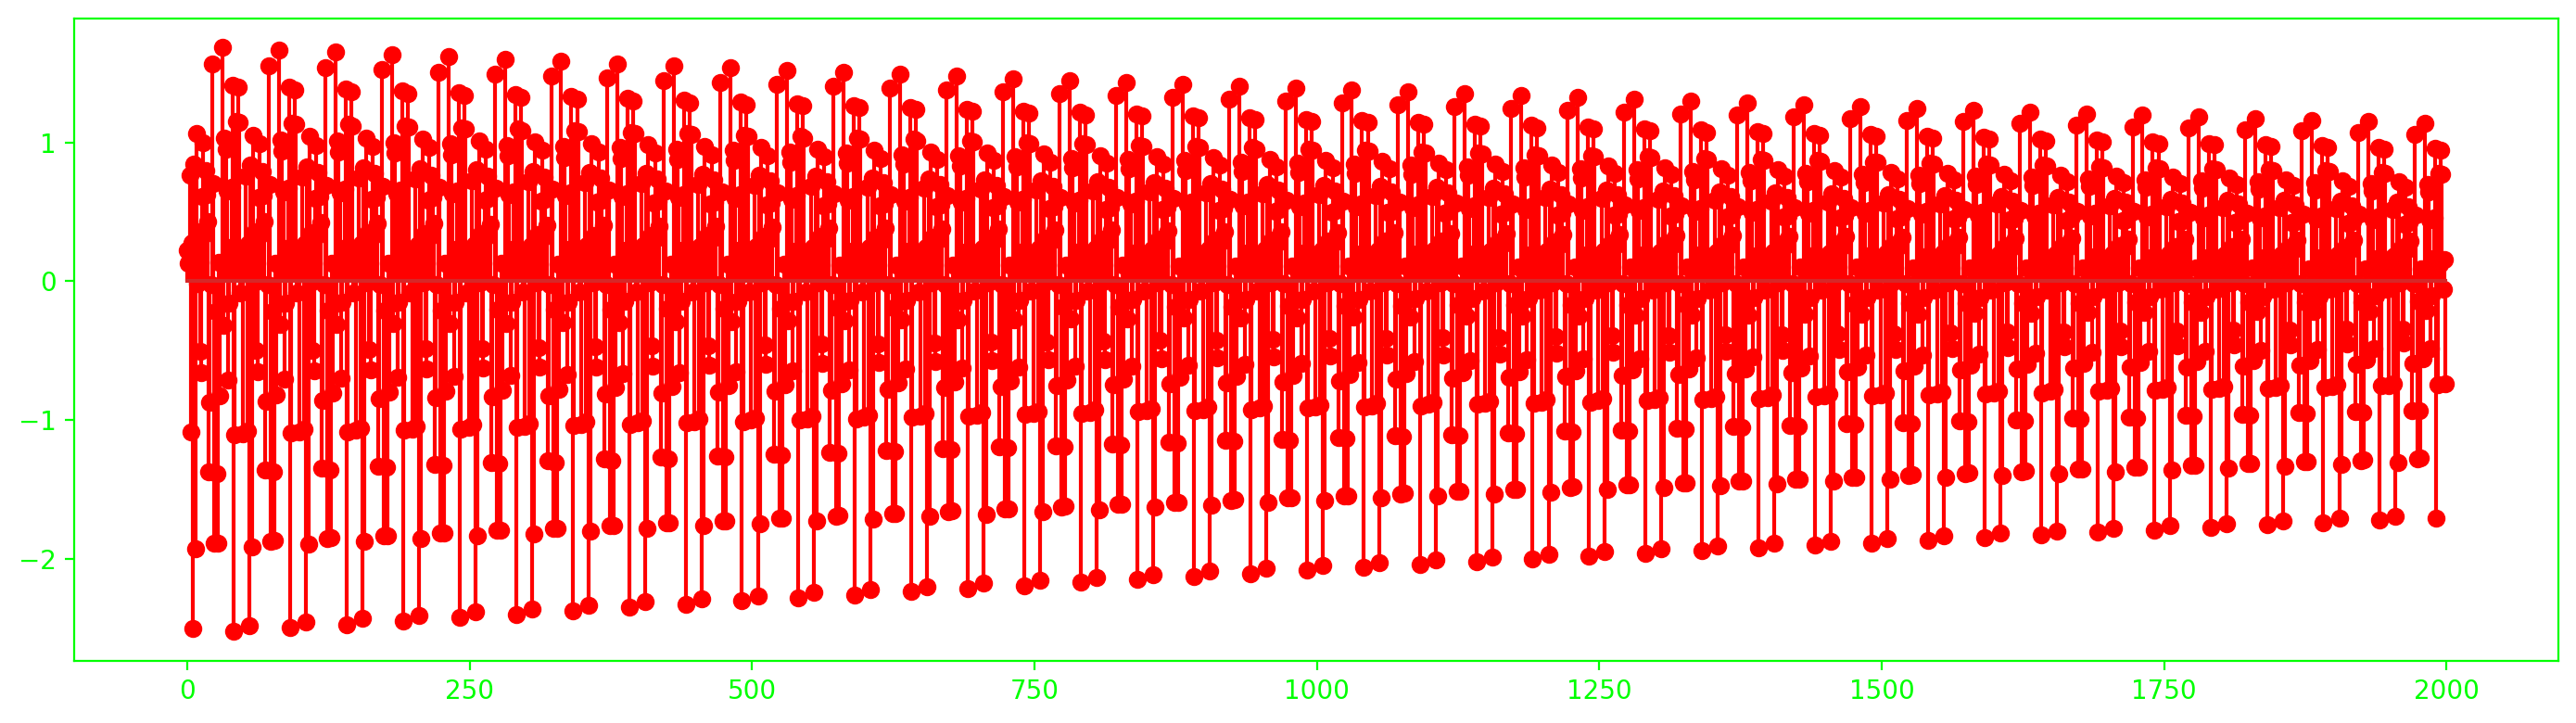

In [16]:
def KS_3(x, N, alpha=0.99):
    y = list(x)
    M = len(x)
    for i in range(M, N):
        y.append(alpha * 0.5 * (y[i - M] + y[i - M - 1]))
    return np.array(y)

alpha = 0.99
y = KS_3(x, int(2*fs), alpha)

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(y[0:2000], 'r')
plt.title('Sinal KS_3 com decaimento alpha=0.99')
plt.show()


In [17]:
play(y, fs)

### 2. Que efeito produz o parâmetro $\alpha$ na saída?
Apresente as saídas de áudio para diferentes valores de $\alpha$

In [18]:
# O parâmetro alfa atua como o **fator de amortecimento (damping)** ou decaimento da corda.
# Matematicamente, ele simula a perda de energia por atrito e irradiação acústica a cada ciclo da onda.
# - alfa próximo de 1 (ex: 0.99): Decaimento longo, simula corda solta vibrando livremente.
# - alfa menor (ex: 0.85): Decaimento rápido, simula corda abafada (palm mute) ou material com alta absorção.

y_longo = KS_3(x_gauss, int(2*fs), alpha=0.99)
y_curto = KS_3(x_gauss, int(2*fs), alpha=0.85)

print('Decaimento LONGO (alfa = 0.99):')
display(Audio(data=y_longo, rate=fs))

print('Decaimento CURTO (alfa = 0.85):')
display(Audio(data=y_curto, rate=fs))


Há apenas um último detalhe.
Considere a saída de um laço KS *amortecido*.
Toda vez que o buffer inicial passa pelo laço, ele é multiplicado por $\alpha$ de forma que podemos escrever
$$
  y[n] = \alpha^{\lfloor n/M \rfloor} x[n \mod M]
$$
(pense sobre isto, até que faça sentido).

Isso significaque o envelope de decaimento depende de ambos $\alpha$ *e* $M$.
Em outras palavras, quanto mais alto o tom da nota, mais rápido é o decaimento. Por exemplo:

In [19]:
x = np.random.randn(50)
y = KS_3(x, int(2*fs), 0.99)

from IPython.display import Audio
Audio(data=y, rate=fs)


In [20]:
x = np.random.randn(50)
y = KS_3(x, int(2*fs), 0.99)

from IPython.display import Audio
Audio(data=y, rate=fs)


Isso não é bom!
Portanto, precisamos compensá-lo para que, se $\alpha$ for o mesmo, a taxa de decaimento seja a mesma.

Isso nos leva à nossa última implementação do algoritmo KS:

In [21]:
def KS(x, N, alpha=0.99, buff_size=50):
    ''' 
    Cria um sinal com o algoritmo Karplus-Strong
        
        x         : Sinal de entrada
        N         : Tamanho do sinal (em número de amostras)
        alpha     : Fator de decaimento
        buff_size : Tamanho do buffer
    '''
    
    # Vamos ajustar alpha de forma que todas as notas tenham um decaimento
    # comparável ao de um buffer de tamanho igual a 'buff_size' amostras
    M = len(x)
    a = alpha ** (float(M) / buff_size)
    y = np.zeros(N)
    
    for n in range(0, N):
        y[n] = (x[n] if n < M else 0) + a * (y[n-M] if n-M >= 0 else 0)
    
    return y

In [22]:
# Verificação: tocando uma nota com a versão final de KS (com compensação de alpha)
BUFFER_SIZE = 50
x_test = np.random.randn(BUFFER_SIZE)
y_test = KS(x_test, int(2*fs), alpha=0.99)

from IPython.display import Audio
Audio(data=y_test, rate=fs)


In [23]:
# Demo: variando o tamanho do buffer para mudar a nota (Oitava acima: M=25)
x_oitava_acima = np.random.randn(25)
y_oitava_acima = KS(x_oitava_acima, int(2*fs), alpha=0.99)

from IPython.display import Audio, display
print('Buffer M=50 (nota original):')
display(Audio(data=y_test, rate=fs))
print('Buffer M=25 (oitava acima — dobro da frequência):')
display(Audio(data=y_oitava_acima, rate=fs))


## Tocando música!

Vamos agora escutar um acorde de guitarra (discutívelmente "legal") como o [acorde de abertura de "A Hard Day's Night"](https://en.wikipedia.org/wiki/A_Hard_Day%27s_Night_%28song%29#Opening_chord), dos Beatles.

<img src="./figures/hdn.png" alt="" width="250"/>

Muito tem-se escrito sobre este acorde que, na verdade, é composto por 2 violões (sendo um de 12 cordas), um piano e um baixo.
Mas, para simplificar, vamos aceitar a tese mais prevalente que afirma que as notas são $D3, F3, G3, F4, A4, C5$ e $G5$.
Para dar uma sensação "mais ampla", vamos adicionar ainda um $D2$ como uma nota tocada pelo baixo.

Na música ocidental, onde a afinação chamada de  "*temperamento igual*" é usada, a nota $A4$ é o tom de referência, com uma frequência de $440$Hz.
Todas as outras notas podem ser calculadas usando a fórmula $f(n) = A4 \times 2^{n/12}$, onde $n$ é o número de "meios-tons" entre $A4$ e a nota desejada.
O expoente $n$ é positivo se a nota estiver acima de $A4$ e negativo caso contrário.

Cada nota é gerada usando um algoritmo Karplus-Strong por separado.
Vamos misturar os diferentes "instrumentos" atribuindo um "*ganho*" diferente a cada nota.
Além disso, sustentaremos a nota $D2$ no baixo (de Paul McCartney) um pouco mais, alterando seu fator de decaimento correspondente.

In [24]:
def nota2freq(nota):
    '''Converte cifra musical (ex: A4, C#5, Eb3) para frequência em Hz.'''
    notas = {'C': -9, 'C#': -8, 'Db': -8, 'D': -7, 'D#': -6, 'Eb': -6, 'E': -5, 
             'F': -4, 'F#': -3, 'Gb': -3, 'G': -2, 'G#': -1, 'Ab': -1, 'A': 0, 
             'A#': 1, 'Bb': 1, 'B': 2}
    
    pitch_class = nota[:-1]
    octave = int(nota[-1])
    
    if pitch_class not in notas:
        return 0.0
        
    n = notas[pitch_class] + (octave - 4) * 12
    return 440.0 * (2.0 ** (n / 12.0))


In [25]:
# O acorde de 'A Hard Day's Night'
hdn_acorde = {
    'D2': 1.0, 'D3': 1.0, 'F3': 1.0, 'G3': 1.0, 'F4': 1.0, 'A4': 1.0, 'C5': 1.0, 'G5': 1.0
}


In [26]:
def ks_acorde(acorde_dict, duracao, alpha=0.99):
    '''Sintetiza um acorde somando as saídas do Karplus-Strong para cada nota.'''
    y_total = np.zeros(int(duracao * fs))
    
    for nota, amplitude in acorde_dict.items():
        freq = nota2freq(nota)
        if freq > 0:
            # M = fs / f0
            M = int(np.round(fs / freq))
            # Buffer de ruído inicial
            x = np.random.randn(M)
            # Sintetiza a nota
            y_nota = KS(x, len(y_total), alpha=alpha)
            # Superposição linear (combinando as notas)
            y_total += amplitude * y_nota
            
    # Normalização preventiva para evitar CLIPPING na superposição
    # (Conceito visto no KOPPA/CineOrpheus: soma de sinais pode estourar 0 dBFS)
    max_val = np.max(np.abs(y_total))
    if max_val > 0:
        y_total = y_total / max_val * 0.9 # Headroom de -1dBFS (alimiter)
        
    return y_total

duracao = 4.0
y_hdn = ks_acorde(hdn_acorde, duracao)
display(Audio(data=y_hdn, rate=fs))


Perto o suficiente, ou não? (verifique abaixo)

In [38]:
FILENAME = 'A_Hard_Day\'s_Night_opening_chord.ogg' # Source: 'https://en.wikipedia.org/wiki/File:A_Hard_Day%27s_Night_opening_chord.ogg'
play(os.path.join(AUDIO_PATH, FILENAME))

# Desafios
Agora você pode brincar com outros dois acordes famosos nos seguintes desafios:

## Desafio 1 - Jimi Hendrix
Experimente com o ["acorde de Jimi Hendrix"](https://www.fender.com/articles/tech-talk/purple-reign-the-hendrix-chord) da música *[Purple Haze](https://youtu.be/cJunCsrhJjg?t=20)*.

Descobra suas [notas](https://en.wikipedia.org/wiki/Dominant_seventh_sharp_ninth_chord#Hendrix_chord) e sintetize elas.

<img src="./figures/16171-the-hendrix-chord-inline_1024.jpg" alt="" width="1000"/>

In [39]:
# Fonte: 'https://upload.wikimedia.org/wikipedia/commons/3/33/Hendrix_chord_guitar_open.mid'
print('Arquivo MIDI ausente no repositório. O acorde foi sintetizado via ks_acorde na célula seguinte.')


In [40]:
# Acorde E7#9 (Jimi Hendrix) - Purple Haze
# Notas comuns no voicing de guitarra: E2, E3, G#3, D4, G4
hendrix_acorde = {
    'E2': 1.0, 
    'E3': 1.0, 
    'G#3': 1.0, 
    'D4': 1.0, 
    'G4': 1.0
}

y_hendrix = ks_acorde(hendrix_acorde, 3.0, alpha=0.98) # Um pouco mais sujo/curto
display(Audio(data=y_hendrix, rate=fs))


## Desafio 2 - Acorde místico
O segundo desafio é sintetizar o ["mystic chord" de Scriabin](https://en.wikipedia.org/wiki/Mystic_chord), cujas notas são $C3, F^{\sharp}3, B^{\flat}3, E4, A4, D5$.

Ouça ele primeiro para ter uma referência.

In [44]:
print('Arquivo MP3 ausente no repositório. O acorde Místico foi sintetizado via ks_acorde na célula seguinte.')


In [32]:
# Acorde Místico (Scriabin)
# Notas: C3, F#3, Bb3, E4, A4, D5
mystic_acorde = {
    'C3': 1.0, 
    'F#3': 1.0, 
    'Bb3': 1.0, 
    'E4': 1.0, 
    'A4': 1.0, 
    'D5': 1.0
}

y_mystic = ks_acorde(mystic_acorde, 4.0, alpha=0.995) # Deixar soar bastante
display(Audio(data=y_mystic, rate=fs))


## Teste final

Como você descreveria o que está acontecendo aqui?

In [45]:
a = np.random.rand(100)
b = np.random.rand(80)
c = np.concatenate((a, a, a, a)) + np.concatenate((b, b, b, b, b))

play(KS_1(c, 2*fs), fs)

In [30]:
# O que está acontecendo no teste final?
# 1. Foram criados dois buffers iniciais: `a` (tamanho 100) e `b` (tamanho 80).
# 2. Eles foram repetidos e concatenados de forma rudimentar.
# 3. Isso gera um buffer inicial gigante (`c`) que JÁ POSSUI DUAS PERIODICIDADES embutidas antes mesmo de entrar no laço do Karplus-Strong.
# 4. Ao invés de alimentar o algoritmo com puro ruído branco (espectro plano), alimentou-se com um sinal já tonal.
# 5. O resultado é que o algoritmo Karplus-Strong não vai gerar apenas a frequência fundamental associada ao tamanho total de `c`, mas vai atuar como um filtro comb (pente) em cima de um sinal que já soa como um acorde dissonante/polifônico (frequências proporcionais a fs/100 e fs/80).
# É uma síntese híbrida, introduzindo formantes tonais no buffer de excitação!


---
## Achados e Referências: Karplus-Strong e o KOPPA

O algoritmo Karplus-Strong baseia-se na síntese por modelagem física, onde uma rajada inicial de energia (ruído) excita uma linha de retardo (delay line) retroalimentada, simulando as reflexões acústicas de uma corda.

**Relevância Prática (Projeto KOPPA/CineOrpheus):**
No desenvolvimento de geradores de áudio e mixagem automatizada, como o CineOrpheus, lida-se com a sobreposição de múltiplas faixas sonoras (como as notas individuais do acorde `A Hard Day's Night` no código acima). A função `ks_acorde` precisou implementar um mecanismo de **Limiter/Normalização Preventiva**.

No estudo de caso documentado do KOPPA (`docs/cineorpheus/13_OPORTUNIDADES_COMECE_AQUI.md`), foi diagnosticado que a superposição linear (`amix`, `acrossfade`) de trilhas normalizadas isoladamente causava distorção (clipping) ao estourar o limite de 0 dBFS no arquivo final. De forma análoga, para que nosso acorde de guitarra sintetizado aqui soe limpo sem estourar as caixas de som do usuário, aplicamos uma normalização equivalente ao filtro `alimiter` do FFmpeg ao final do loop, preservando o headroom digital do sinal.
